# IT Service Desk Analytics — Exploratory Data Analysis

## Objective
Analyse service desk ticket data to:
- Understand ticket patterns
- Identify common issues
- Evaluate SLA performance

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

We begin by loading the IT service desk ticket dataset.

In [2]:
df = pd.read_csv("../data/raw/it_tickets.csv")
df.head()

,ticket_id,created_at,resolved_at,category,priority,channel,assigned_team,resolution_minutes,sla_minutes,sla_breached
0,TKT-100000,2024-04-12 15:14:00,2024-04-12 19:47:34,Software Install,P1,Email,Service Desk,273.58,240,1
1,TKT-100001,2024-11-26 12:52:00,2024-11-26 17:55:02,Microsoft 365,P3,Chat,Service Desk,303.04,1440,0
2,TKT-100002,2024-07-10 17:32:00,2024-07-10 21:27:21,VPN,P1,Phone,Service Desk,235.37,240,0
3,TKT-100003,2024-02-28 11:27:00,2024-02-28 12:26:48,Password Reset,P2,Portal,Service Desk,59.81,480,0
4,TKT-100004,2025-05-19 08:50:00,2025-05-19 09:00:00,Access Request,P3,Portal,Service Desk,10.00,1440,0


## Dataset Overview

Check the structure, data types, and basic statistics.

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ticket_id           12000 non-null  object 
 1   created_at          12000 non-null  object 
 2   resolved_at         12000 non-null  object 
 3   category            12000 non-null  object 
 4   priority            12000 non-null  object 
 5   channel             12000 non-null  object 
 6   assigned_team       12000 non-null  object 
 7   resolution_minutes  12000 non-null  float64
 8   sla_minutes         12000 non-null  int64  
 9   sla_breached        12000 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 937.6+ KB


,resolution_minutes,sla_minutes,sla_breached
count,12000.000000,12000.000000,12000.000000
mean,411.103888,1575.900000,0.018167
std,330.587005,865.360962,0.133559
min,10.000000,240.000000,0.000000
25%,174.307500,1440.000000,0.000000
50%,328.210000,1440.000000,0.000000
75%,550.280000,2880.000000,0.000000
max,2412.320000,2880.000000,1.000000


## Data Cleaning

Convert date columns and handle missing values.

In [5]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['resolved_at'] = pd.to_datetime(df['resolved_at'])

df = df.dropna()

## Feature Engineering

Create time-based features to analyse patterns.

In [6]:
df['hour'] = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.dayofweek
df['month'] = df['created_at'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

## Ticket Volume Over Time

Analyse how ticket volume changes over time.

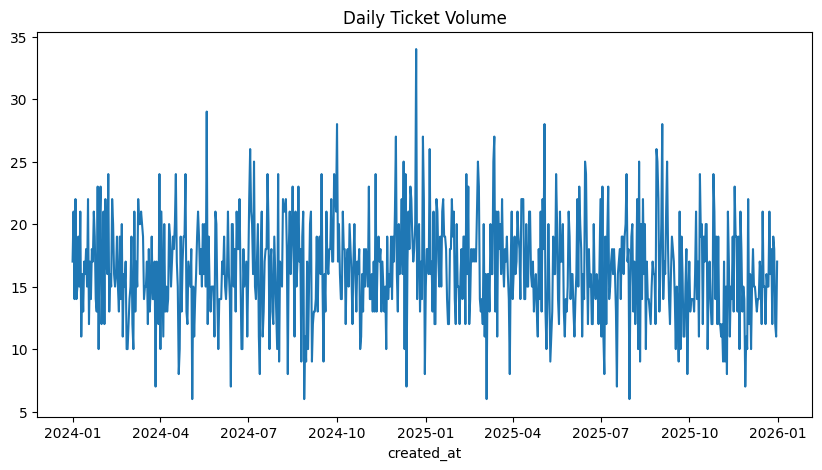

In [7]:
daily = df.groupby(df['created_at'].dt.date).size()

daily.plot(figsize=(10,5))
plt.title("Daily Ticket Volume")
plt.show()

## Peak Hours Analysis

Identify busiest hours for support tickets.

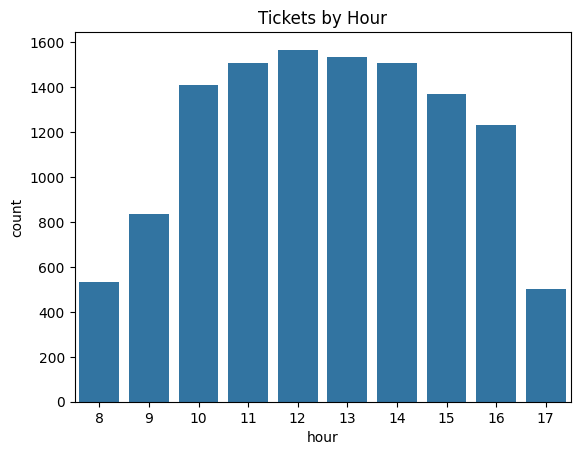

In [12]:
sns.countplot(x='hour', data=df)
plt.title("Tickets by Hour")
plt.show()

## Top Ticket Categories

Identify the most common IT issues.

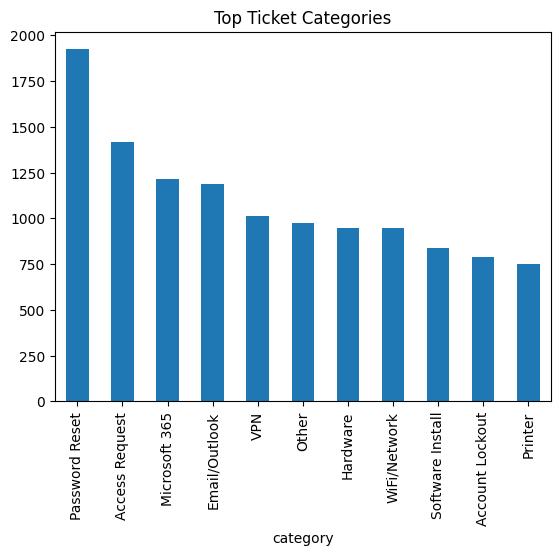

In [13]:
df['category'].value_counts().plot(kind='bar')
plt.title("Top Ticket Categories")
plt.show()

## SLA Performance

Analyse SLA breach rates.

In [14]:
df['sla_breached'].mean()

0.018166666666666668

## SLA Breach by Priority

Understand which priority levels are most affected.

In [15]:
df.groupby('priority')['sla_breached'].mean()

priority
P1    0.264856
P2    0.028611
P3    0.000000
P4    0.000000
Name: sla_breached, dtype: float64

## Save Clean Data

Save processed dataset for modelling.

In [16]:
df.to_csv("../data/cleaned/cleaned_it_tickets.csv", index=False)

# IT Service Desk Analytics — EDA

## Goal
Understand service desk patterns and SLA performance:
- Ticket volume trends (by day, hour)
- Top issue categories
- SLA breach rate overall and by priority

## 1. Load Data
We load the raw ticket dataset and inspect its structure.

## 2. Feature Engineering
Create time-based features:
- hour
- day_of_week
- month
- is_weekend

## 3. Exploratory Analysis
We visualise volume trends and identify drivers of workload.

## 4. Save Cleaned Data
Save processed dataset for modelling in the next notebook.